In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Get sklearn! https://scikit-learn.org/stable/
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("/Users/danisanchez/Downloads/LA_AQS_2023.csv")

In [3]:
print(df.columns.tolist())

['State Code', 'County Code', 'Site Number', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Duration Description', 'Pollutant Standard', 'Date (Local)', 'Year', 'Day In Year (Local)', 'Units of Measure', 'Exceptional Data Type', 'Nonreg Observation Count', 'Observation Count', 'Observation Percent', 'Nonreg Arithmetic Mean', 'Arithmetic Mean', 'Nonreg First Maximum Value', 'First Maximum Value', 'First Maximum Hour', 'AQI', 'Daily Criteria Indicator', 'Tribe Name', 'State Name', 'County Name', 'City Name', 'Local Site Name', 'Address', 'MSA or CBSA Name', 'Data Source']


In [4]:
o3_df = df[df['Parameter Name'].str.contains('Ozone', case=False, na=False)]
o3_df = o3_df[['State Code', 'County Code', 'Site Number', 'Date (Local)', 'Arithmetic Mean', 'Units of Measure']]
o3_df = o3_df.rename(columns={'Arithmetic Mean': 'O3_Value', 'Units of Measure': 'O3_Units'})

# Separate Nitrogen Dioxide data
no2_df = df[df['Parameter Name'].str.contains('Nitrogen dioxide', case=False, na=False)]
no2_df = no2_df[['State Code', 'County Code', 'Site Number', 'Date (Local)', 'Arithmetic Mean', 'Units of Measure']]
no2_df = no2_df.rename(columns={'Arithmetic Mean': 'NO2_Value', 'Units of Measure': 'NO2_Units'})


In [5]:
df_merged = pd.merge(
    o3_df, no2_df, 
    on=['State Code', 'County Code', 'Site Number', 'Date (Local)'], 
    how='inner'
)

In [6]:
df_clean = df_merged.dropna(subset=['O3_Value', 'NO2_Value'])

In [7]:
o3_unit = df_clean['O3_Units'].iloc[0] if not df_clean.empty else "ppm"
no2_unit = df_clean['NO2_Units'].iloc[0] if not df_clean.empty else "ppb"

In [8]:
X_epa = df_clean[['NO2_Value']].values  # Independent variable
y_epa = df_clean['O3_Value'].values  

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_epa, y_epa, test_size=0.20, random_state=42
)

In [10]:
epa_model = LinearRegression()
epa_model.fit(X_train, y_train)

y_pred = epa_model.predict(X_test)

In [11]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- MODEL RESULTS ---")
print(f"Model Equation: O3 = ({epa_model.coef_[0]:.4f} * NO2) + {epa_model.intercept_:.4f}")
print(f"Test RMSE: {rmse:.4f} {o3_unit}")
print(f"Test R² Score: {r2:.4f}")

--- MODEL RESULTS ---
Model Equation: O3 = (-0.0007 * NO2) + 0.0388
Test RMSE: 0.0065 Parts per million
Test R² Score: 0.3289


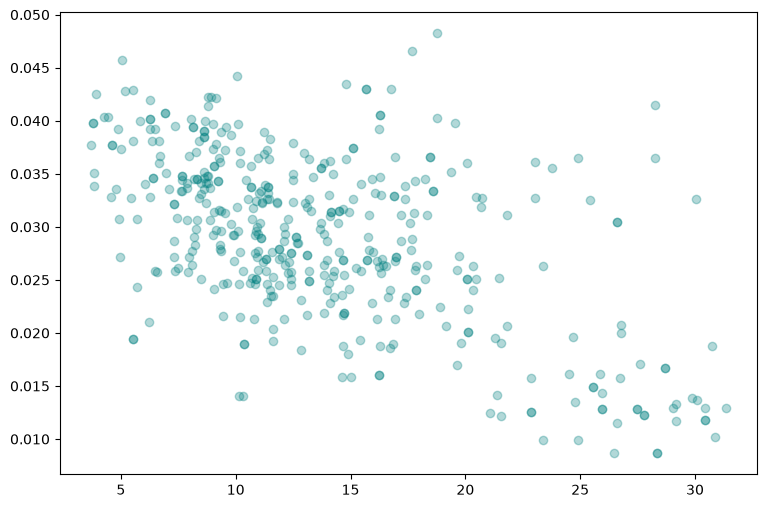

In [12]:
plt.figure(figsize=(9, 6))
plt.scatter(X_test, y_test, alpha=0.3, color='teal', label='Actual Test Data')

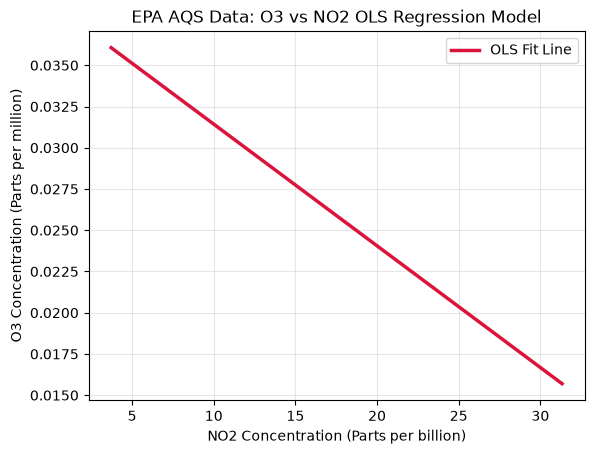

In [16]:
sort_idx = np.argsort(X_test.flatten())
plt.plot(X_test[sort_idx], y_pred[sort_idx], color='crimson', linewidth=2.5, label='OLS Fit Line')
plt.xlabel(f'NO2 Concentration ({no2_unit})')
plt.ylabel(f'O3 Concentration ({o3_unit})')
plt.title('EPA AQS Data: O3 vs NO2 OLS Regression Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
df_co2 = pd.read_csv('/Users/danisanchez/Downloads/ManuaLoa_CO2 (2).csv')
print(df_co2.columns.tolist())
print(df_co2.head(3))

['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays', 'sdev', 'unc']
   year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0  1958      3     1958.2027   315.70          314.43     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99
2  1958      5     1958.3699   317.51          314.71     -1 -9.99 -0.99


In [19]:
df_co2 = df_co2[df_co2['average'] > 0]

In [20]:
print(f"Loaded Mauna Loa dataset with {len(df_co2)} valid rows.")

Loaded Mauna Loa dataset with 791 valid rows.


In [21]:
train_df = df_co2[df_co2['decimal date'] < 2000]
test_df = df_co2[df_co2['decimal date'] >= 2000]

X_train = train_df[['decimal date']].values
y_train = train_df['average'].values

X_test = test_df[['decimal date']].values
y_test = test_df['average'].values

print(f"Training samples (Pre-2000): {len(X_train)}")
print(f"Testing samples (Post-2000): {len(X_test)}\n")

Training samples (Pre-2000): 502
Testing samples (Post-2000): 289



In [22]:
co2_model = LinearRegression()
co2_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.32]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2281
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[270.6]


In [24]:
y_pred_test = co2_model.predict(X_test)

# Calculate metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print("MAUNA LOA MODEL RESULTS")
print(f"Pre-2000 Fit Equation: CO2 = ({co2_model.coef_[0]:.4f} * Date) + {co2_model.intercept_:.4f}")
print(f"Post-2000 Test RMSE: {test_rmse:.4f} ppm")
print(f"Post-2000 Test R² Score: {test_r2:.4f}")

MAUNA LOA MODEL RESULTS
Pre-2000 Fit Equation: CO2 = (1.3233 * Date) + -2280.5911
Post-2000 Test RMSE: 14.1508 ppm
Post-2000 Test R² Score: 0.1900


In [26]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

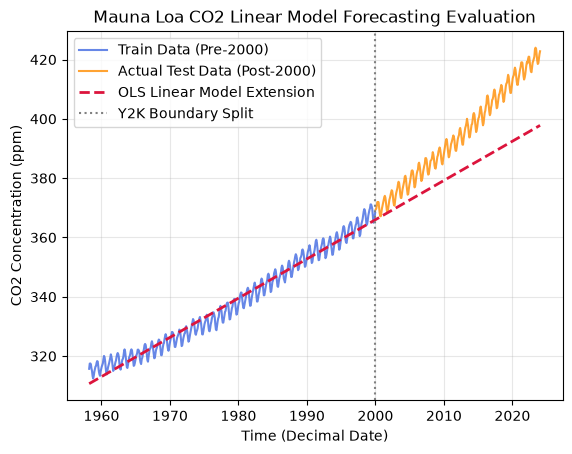

In [31]:
plt.plot(train_df['decimal date'], y_train, color='royalblue', label='Train Data (Pre-2000)', alpha=0.8)
plt.plot(test_df['decimal date'], y_test, color='darkorange', label='Actual Test Data (Post-2000)', alpha=0.8)

all_dates = df_co2[['decimal date']].values
y_all_pred = co2_model.predict(all_dates)
plt.plot(df_co2['decimal date'], y_all_pred, color='crimson', linestyle='--', linewidth=2, label='OLS Linear Model Extension')

plt.axvline(x=2000, color='gray', linestyle=':', label='Y2K Boundary Split')

plt.xlabel('Time (Decimal Date)')
plt.ylabel('CO2 Concentration (ppm)')
plt.title('Mauna Loa CO2 Linear Model Forecasting Evaluation')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()